In [3]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [4]:
# load dataset
from google.colab import files
uploaded = files.upload()

Saving Student Mental health.csv to Student Mental health.csv


In [5]:
df= pd.read_csv("Student Mental health.csv")
df.head(10)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,8/7/2020 12:31,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,8/7/2020 12:35,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


In [ ]:
df.shape

(101, 11)

In [ ]:
df.dtypes

,0
Timestamp,object
Choose your gender,object
Age,float64
What is your course?,object
Your current year of Study,object
What is your CGPA?,object
Marital status,object
Do you have Depression?,object
Do you have Anxiety?,object
Do you have Panic attack?,object


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.dtypes

,0
Timestamp,datetime64[ns]
Choose your gender,object
Age,float64
What is your course?,object
Your current year of Study,object
What is your CGPA?,object
Marital status,object
Do you have Depression?,object
Do you have Anxiety?,object
Do you have Panic attack?,object


In [ ]:
df.isna().sum()

,0
Timestamp,23
Choose your gender,0
Age,1
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [ ]:
#Rows with missing Timestamp values were removed because time data cannot be reliably estimated, and only 23 values were missing.
df = df.dropna(subset=['Timestamp'])
df.isna().sum()

,0
Timestamp,0
Choose your gender,0
Age,1
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [ ]:
#The missing value in Age was filled using the median to maintain the data distribution and avoid the effect of outliers.
df['Age'] = df['Age'].fillna(df['Age'].median())
df.isna().sum()

,0
Timestamp,0
Choose your gender,0
Age,0
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [ ]:
df.shape

(78, 11)

In [6]:
# Detect and handle outliers using IQR.

df['Year_numeric'] = df['Your current year of Study'].str.extract(r'(\d)').astype(float)

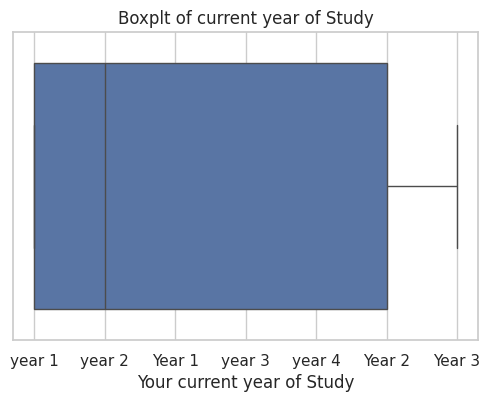

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Your current year of Study'])

plt.title('Boxplt of current year of Study')
plt.show()

# No outliers

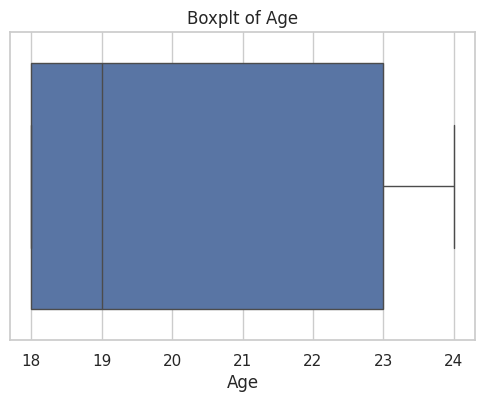

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Year_numeric,CGPA_numeric


In [ ]:
# Detect and handle outliers using IQR.

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])

plt.title('Boxplt of Age')
plt.show()

# No outliers

In [ ]:
# Outlier detection using the IQR method was performed on the Age column. Even though no outliers were detected, the process was applied to demonstrate how outliers can be identified using the IQR approach.
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
outliers.head(15)

df_no_outliers = df[(df['Age'] >= lower) & (df['Age'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (78, 13)
df without outliers:  (78, 13)


In [ ]:
df[['Age','CGPA_numeric']].head(10)

,Age,CGPA_numeric
0,0.000000,0.816697
1,0.500000,0.816697
2,0.166667,0.816697
3,0.666667,0.816697
4,0.833333,0.816697
5,0.166667,1.000000
6,0.833333,1.000000
7,0.000000,1.000000
8,0.166667,0.635209
9,0.000000,1.000000


In [ ]:
# Normalize numerical features using Min-Max.
# Min-Max normalization was applied to the numerical features such as Age to scale the values between 0 and 1.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Age','CGPA_numeric']].copy()
df_scaled[['Age','CGPA_numeric']] = scaler.fit_transform(df_scaled)
df_scaled.head()


,Age,CGPA_numeric
0,0.000000,0.816697
1,0.500000,0.816697
2,0.166667,0.816697
3,0.666667,0.816697
4,0.833333,0.816697


In [ ]:
# Normalize numerical features using Z-score.
# Standardization was applied to the numerical features (Age and CGPA_numeric) using StandardScaler to transform the data so that it has a mean of 0 and a standard deviation of 1.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Age','CGPA_numeric']].copy()
df_standardized[['Age','CGPA_numeric']] = scaler.fit_transform(df_standardized)
df_standardized.head()

,Age,CGPA_numeric
0,-1.021814,-0.295501
1,0.185784,-0.295501
2,-0.619281,-0.295501
3,0.588317,-0.295501
4,0.990850,-0.295501


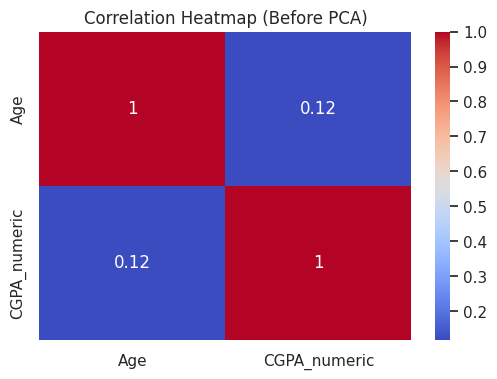

In [ ]:
# Apply PCA only if the numerical features show a correlation.
# Check Correlation

plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Age','CGPA_numeric']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

# The correlation between Age and CGPA_numeric is very weak (0.12).

In [ ]:
# Data Reduction – Principal Component Analysis (PCA)

from sklearn.decomposition import PCA

X = df_standardized[['Age','CGPA_numeric']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# PCA was applied to the standardized features (Age and CGPA_numeric).
# The first principal component explains about 55.9% of the variance, while the second explains about 44.1%. Together, they capture nearly 100% of the data variance.

Explained Variance Ratio: [0.55886586 0.44113414]


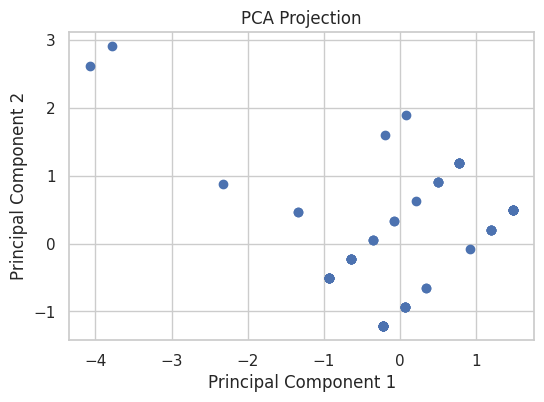

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()